FOUND SIMULATIONS  10430
FOUND SIMULATIONS  10430


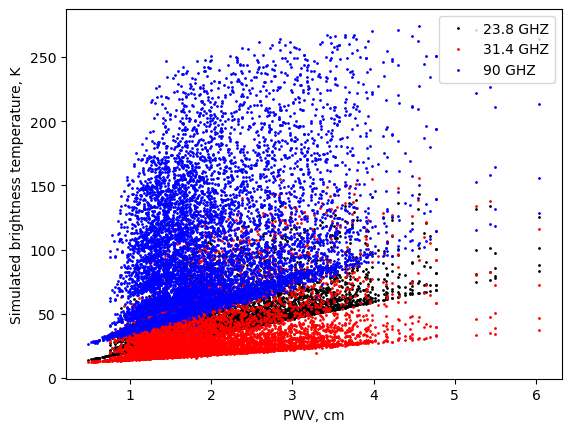

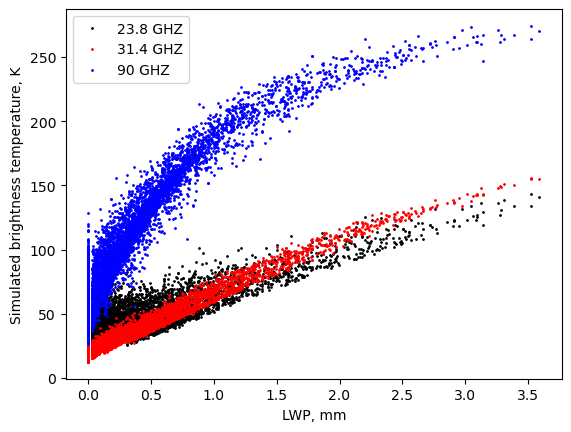

In [1]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors
import pyFUNCTIONS
import os

##PURPOSE: RETRIEVE PRECIPITABLE WATER VAPOR (PWV) AND CLOUD LIQUID WATER PATH (LWP) 
###FROM RADIOMETRIC OBSERVATIONS OF BRIGHTNESS TEMPERATURES AT 3 FREQUENCIES: 23.8, 31.4, AND 90 GHZ
###WE USE THE AMF2 CAPE-K DEPLOYMENT (KCG) AS OUR TEST LOCATION

######THE INSTRUMENT WE ARE SIMULATING (AND THEN USING) IS THE 3-CHANNEL MICROWAVE RADIOMETER (MWR3C)

###METHODOLOGY: A LARGE (5 YEARS) DATASET OF RADIOSONDES IS USED TO GENERATE A SYNTHETIC DATASET
####OF RADIOMETRIC BRIGHTNESS TEMPERATURES. THE RADIOSONDES WITH SIMULATED CLOUDS ARE THE INPUT TO 
####A RADIATIVE TRANSFER CODE THAT GENERATES THE BRIGHTNESS TEMPERATURES ASSOCIATED TO THE 
#########PROVIDED ATMOSPHERIC STATE- THE SIMULATIONS ARE IN THE INPUT FILES:
######### rdmodel1.kcg.au_MWR3C_RPG1 and rdmodel1.kcg.au_MWR3C_RPG2

######THE SIMULATED BRIGHTNESS TEMPERATURES AND CORRESPONDING PWV AND LWP IS OUR 
#######TRAINING AND TESTING DATASET: INPUT=SIMULATED BRIGHTNESS TEMPERATURES-OUTPUT: PWV AND LWP

######## WE DEVELOP AND TEST 2 MODELS: THE FIRST MODEL IS TRAINED USING SIMULATED OBSERVATIONS 
##FROM 2 CHANNELS (23.8 AND 31.4 GHZ); THE SECOND MODEL IS TRAINED USING SIMULATED
#######OBSERVATIONS FROM 3 CHANNELS (23.8, 31.4, AND 90 GHZ)


#######THE TRAINED ML MODEL IS THEN USED WITH 1 DAY OF REAL OBSERVATIONS AND THE DERIVED PWV AND LWP ARE 
###### COMPARED TO THOSE IN THE LEVEL B1 FILE. PWV AND LWP IN THE LEVEL B1 FILES ARE DERIVED
##########WITH A MULTIPLE REGRESSION. REAL OBSERVATIONS ARE IN THE FILE:
#######kcgmwr3cM1.b1.20250420.000000.nc



#####SIMULATIONS PRODUCED USING A RADIATIVE TRANSFER CODE WITH 5 YEARS OF RADIOSONDES
#####NEAR THE KCG SITE#####40°40'50"S, 144°41'23"E
##########READ FILE WITH SIMULATIONS: 23.8 and 31.4 GHZ , PWV, LWP #############
modelfile='../data/rdmodel1.kcg.au_MWR3C_RPG1'
out=pyFUNCTIONS.readmodel(modelfile)
month=out[0]
tb23=out[1]
tb31=out[2]
pwv=out[3]
lwp=out[4]
npt=tb23.shape[0]

##########READ MODEL FILE: 90 GHZ #############
modelfile='../data/rdmodel1.kcg.au_MWR3C_RPG2'
out=pyFUNCTIONS.readmodel(modelfile)
tb90=out[2]
#print(tb90.shape[0])

#############PLOT VARIABLES#####################
plt.figure(1)
plt.plot(pwv,tb23,marker='o',linestyle='none',color='black',markersize=1, label='23.8 GHZ')
plt.xlabel("PWV, cm")
plt.ylabel("Simulated brightness temperature, K")
plt.legend()
plt.plot(pwv,tb31,marker='o',linestyle='none',color='red',markersize=1,label='31.4 GHZ')
plt.legend()
plt.plot(pwv,tb90,marker='o',linestyle='none',color='blue',markersize=1,label='90 GHZ')
plt.legend()
plt.ion()
plt.show()
#input("cont")

plt.figure(2)
plt.plot(lwp,tb23,marker='o',linestyle='none',color='black',markersize=1, label='23.8 GHZ')
plt.xlabel("LWP, mm")
plt.ylabel("Simulated brightness temperature, K")
plt.legend()
plt.plot(lwp,tb31,marker='o',linestyle='none',color='red',markersize=1,label='31.4 GHZ')
plt.legend()
plt.plot(lwp,tb90,marker='o',linestyle='none',color='blue',markersize=1,label='90 GHZ')
plt.legend()
plt.ion()
plt.show()
#input("cont")


LABELS array dimension  (10430, 2)
VALID POINTS  (10272,)
(10272, 2) (10272, 2) (10272, 3)
TRAIN SET DIMENSION  (9244, 2)
TEST SET DIMENSION  (1028, 2)
SCORE 2CH MODEL 0.9852420957624479
SCORE 3CH MODEL 0.9939226642880771
2 CHANNEL MODEL MSE  [0.00995437 0.00252188]
3 CHANNEL MODEL MSE  [0.00479774 0.00054079]


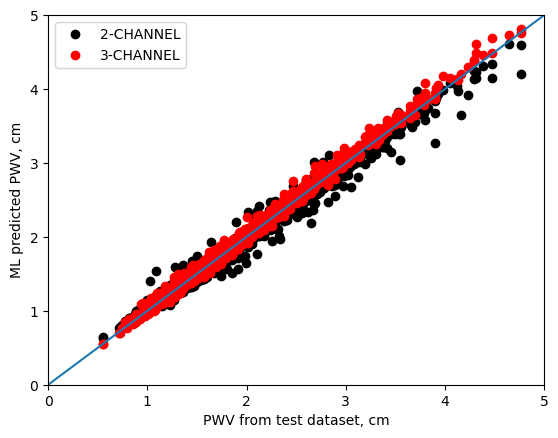

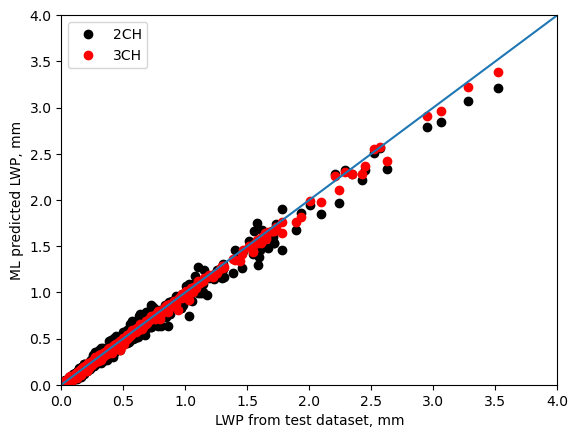

In [2]:
###########ADD NOISE TO MODELED BRIGHTNESS TEMPERATURE AND DEFINE ML MODEL

mean = 0         # Centered at zero to avoid shifting the point
std_devK = 0.5    # measurement uncertainty (sigma) K
std_devW = 0.3
# Generate noise array
noise23 = np.random.normal(mean, std_devK, npt)
#print(noise23[0:20])
noise31 = np.random.normal(mean, std_devK, npt)
#print(noise31[0:20])
noise90 = np.random.normal(mean, std_devW, npt)

tb23wnoise=tb23+noise23
tb31wnoise=tb31+noise31
tb90wnoise=tb90+noise90

########DEFINE FEATURES########
feature2ch=np.full((npt, 2),np.nan)   ###THIS IS TO BUILD A MODEL USING 2 FREQUENCIES 23.8 and 31.4 GHz
feature2ch[:,0] = tb23wnoise
feature2ch[:,1] = tb31wnoise

feature3ch=np.full((npt, 3),np.nan)   ###THIS IS TO BUILD A MODEL USING 3 FREQUENCIES 23.8 and 31.4 and 90 GHz
feature3ch[:,0] = tb23wnoise
feature3ch[:,1] = tb31wnoise
feature3ch[:,2] = tb90wnoise
######################################

##########DEFINE LABEL####
label=np.full((npt, 2),np.nan)
label[:,0]=pwv
label[:,1]=lwp
print('LABELS array dimension ', label.shape)

############ELIMINATE NAN##############
goodindx=np.array([])
for jj in range (0, npt):   ###CHECK EACH TIME STEP
  foo=label[jj,:]
  nancount=np.count_nonzero(np.isnan(foo))
  if (nancount == 0):   ####IF THERE ARE NO NANS
    goodindx=np.append(goodindx, jj)  ####ADD TO GOOD INDEX LIST
  ###################
#############
print('VALID POINTS ', goodindx.shape)
nval=goodindx.shape[0]

label=label[goodindx.astype(int),:]
feature2ch=feature2ch[goodindx.astype(int),:]
feature3ch=feature3ch[goodindx.astype(int),:]
print(label.shape, feature2ch.shape, feature3ch.shape)

##########SPLIT TRAINING AND TESTING##############################
from sklearn.model_selection import train_test_split
indices = np.arange(nval)
train_indx, test_indx = train_test_split(indices, test_size=0.1, shuffle=True)

feature2ch_train=feature2ch[train_indx,:]
feature3ch_train=feature3ch[train_indx,:]
label_train=label[train_indx]
print('TRAIN SET DIMENSION ', feature2ch_train.shape)
ntrain=feature2ch_train.shape[0]

feature2ch_test=feature2ch[test_indx,:]
feature3ch_test=feature3ch[test_indx,:]
label_test=label[test_indx]
print('TEST SET DIMENSION ', feature2ch_test.shape)
ntest=feature2ch_test.shape[0]

##################CREATE THE MODEL##############
###########ML MODEL #################
from sklearn import preprocessing
scaler2ch = preprocessing.StandardScaler().fit(feature2ch_train)
feature2ch_train_scaled = scaler2ch.transform(feature2ch_train)
feature2ch_test_scaled = scaler2ch.transform(feature2ch_test)

scaler3ch = preprocessing.StandardScaler().fit(feature3ch_train)
feature3ch_train_scaled = scaler3ch.transform(feature3ch_train)
feature3ch_test_scaled = scaler3ch.transform(feature3ch_test)

from sklearn.neural_network import MLPRegressor
nnod=200
model = MLPRegressor(hidden_layer_sizes=(nnod,nnod,nnod,nnod),activation='relu',alpha=0.0001,solver='adam',max_iter=5000)
#model3ch = MLPRegressor(hidden_layer_sizes=(nnod,nnod,nnod,nnod),activation='relu',alpha=0.0001,solver='adam',max_iter=5000)

############# TRAIN 2 CHANNEL MODEL ############
import joblib
modelfit2ch=model.fit(feature2ch_train_scaled, label_train)
print('SCORE 2CH MODEL',modelfit2ch.score(feature2ch_train_scaled, label_train))
label_predict2ch = modelfit2ch.predict(feature2ch_test_scaled) ###APPLY TO TEST SET
joblib.dump(modelfit2ch, 'modelfit2ch')  ###DUMP THE MODEL TO USE LATER ON

############# TRAIN 3 CHANNEL MODEL ############
modelfit3ch=model.fit(feature3ch_train_scaled, label_train)
print('SCORE 3CH MODEL',modelfit3ch.score(feature3ch_train_scaled, label_train))
label_predict3ch = modelfit3ch.predict(feature3ch_test_scaled) ###APPLY TO TEST SET
joblib.dump(modelfit3ch, 'modelfit3ch')  ###DUMP THE MODEL TO USE LATER ON

############ERROR#############################
from sklearn.metrics import mean_squared_error
mse2ch=mean_squared_error(label_test, label_predict2ch, multioutput='raw_values')
print('2 CHANNEL MODEL MSE ', mse2ch)
mse3ch=mean_squared_error(label_test, label_predict3ch, multioutput='raw_values')
print('3 CHANNEL MODEL MSE ', mse3ch)

#############PLOT PREDICTED PWV and LWP VALUE (y-axis) vs TEST values
plt.figure(3)
plt.plot(label_test[:,0],label_predict2ch[:,0],color='black',marker='o', linestyle='None',label='2-CHANNEL')
plt.xlabel("PWV from test dataset, cm")
plt.ylabel("ML predicted PWV, cm")
plt.legend()
plt.plot(label_test[:,0],label_predict3ch[:,0],color='red',marker='o', linestyle='None',label='3-CHANNEL')
plt.legend()

plt.axline((0, 0), slope=1)
plt.xlim(0,5)
plt.ylim(0,5)
plt.ion()
plt.show()

plt.figure(2)
plt.plot(label_test[:,1],label_predict2ch[:,1],color='black',marker='o', linestyle='None',label='2CH')
plt.xlabel("LWP from test dataset, mm")
plt.ylabel("ML predicted LWP, mm")
plt.legend()
plt.plot(label_test[:,1],label_predict3ch[:,1],color='red',marker='o', linestyle='None',label='3CH')
plt.legend()
plt.axline((0, 0), slope=1)
plt.xlim(0,4)
plt.ylim(0,4)
plt.ion()
plt.show()


NUMBER OF MWR3c b1 OBSERVATIONS  67023


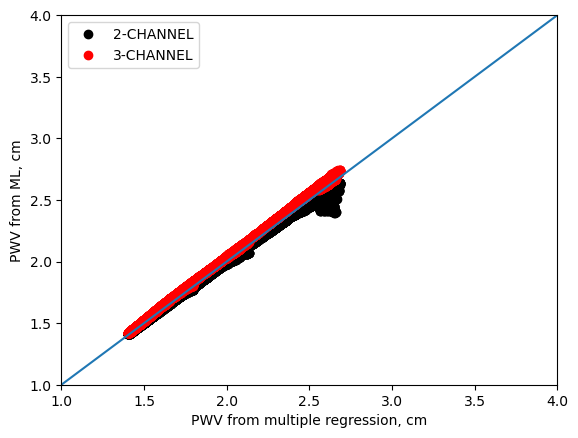

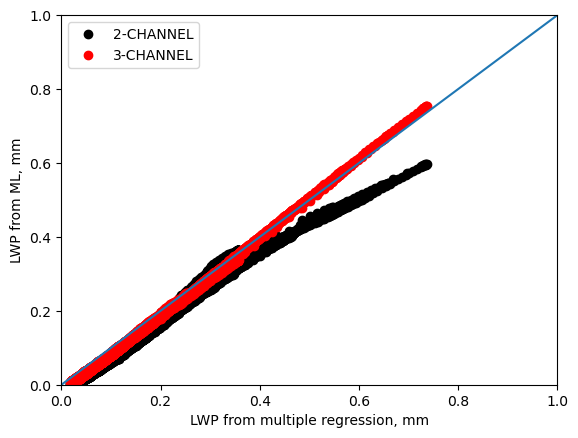

In [3]:
##############APPLY MODEL TO ReAL MWR3C DATA#######

#####READ SAMPLE netcdf file #############################
#############IN THIS FILE THE PWV and LWP RETRIEVALS are FROM 3-channel MULTIPLE REGRESSION
mwr3cfile='../data/kcgmwr3cM1.b1.20250420.000000.nc'
out=pyFUNCTIONS.readmwr3cb1(mwr3cfile)
jtime=out[0]
lwp=out[1]
pwv=out[2]
tbsky23=out[3]
tbsky31=out[4]
tbsky90=out[5]
nobs=out[7]

########DEFINE FEATURES########
tbsky2ch=np.full((nobs, 2),np.nan)   ###OBSERVATIONS AT FREQUENCIES 23.8 and 31.4 GHz
tbsky2ch[:,0] = tbsky23
tbsky2ch[:,1] = tbsky31

tbsky3ch=np.full((nobs, 3),np.nan)   ###OBSERVATIONS AT FREQUENCIES 23.8, 31.4 and 90 GHz
tbsky3ch[:,0] = tbsky23
tbsky3ch[:,1] = tbsky31
tbsky3ch[:,2] = tbsky90

#######SCALE WITH DEFINED SCALER AND LOAD MODELS##############
tbsky2ch_scaled = scaler2ch.transform(tbsky2ch)
loaded_model =joblib.load('modelfit2ch')
retrieved2ch=loaded_model.predict(tbsky2ch_scaled) ###APPLY 2CH MODEL TO MWR OBSERVATIONS

tbsky3ch_scaled = scaler3ch.transform(tbsky3ch)
loaded_model =joblib.load('modelfit3ch')
retrieved3ch=loaded_model.predict(tbsky3ch_scaled) ###APPLY 2CH MODEL TO MWR OBSERVATIONS

#############PLOT ML PWV and LWP VALUE (y-axis) vs STAT RET values
plt.figure(4)
plt.plot(pwv,retrieved2ch[:,0],color='black',marker='o', linestyle='None',label='2-CHANNEL')
plt.xlabel("PWV from multiple regression, cm")
plt.ylabel("PWV from ML, cm")
plt.legend()
plt.plot(pwv,retrieved3ch[:,0],color='red',marker='o', linestyle='None',label='3-CHANNEL')
plt.legend()
plt.axline((0, 0), slope=1)
plt.xlim(1,4)
plt.ylim(1,4)
plt.ion()
plt.show()

plt.figure(5)
plt.plot(lwp,retrieved2ch[:,1],color='black',marker='o', linestyle='None',label='2-CHANNEL')
plt.xlabel("LWP from multiple regression, mm")
plt.ylabel("LWP from ML, mm")
plt.legend()
plt.plot(lwp,retrieved3ch[:,1],color='red',marker='o', linestyle='None',label='3-CHANNEL')
plt.legend()
plt.axline((0, 0), slope=1)
plt.xlim(0,1)
plt.ylim(0,1)
plt.ion()
plt.show()


